<img src="images/purple_net.jpeg" alt="purple_net"> 

# **<font color="purple">ANN Classification -- Lab 3</font>**
### **<font color="purple">Prof. Tiziana Ligorio</font>**
### **<font color="purple">Hunter College of The City University of New York</font>**

---
---

In [ ]:
!pip install lightning -q

# Make a copy of this notebook in your drive so you can edit it

# Introduction
In Lab 2 we looked at the Perceptron and saw it is essentially a linear binary classifier that feeds a weighted sum through a step function.  
In this lab we will explore the **application of a non-linear activation function** instead of the step function and its effects. We will finally introduce a feed forward, fully connected neural network.

Topics covered in this notebook are:
* [Artificial Non-linear Dataset: Spirals](#data)
* [Training a Perceptron on Non-linearly Separable data](#perceptron)
* [Functional Units](#units)
  * [Sigmoid](#sigmoid)
  * [Hyperbolic Tangent](tanh)
  * [Rectified Linear Unit](#relu)
* [Artificial Neural Networks](#ann)
  * [How to initialize and compile a model](#initialize)
  * [How to train the model](#train)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Before we begin, let's set a random seed for reproducibility. The random seed is a starting point for the random number generator. When we use the same seed over different executions, the same random number sequences will be generated, and thereby produce the same results across runs.
This will not always work with PyTorch. Randomness is hard to control because its optimization implementation has many operation-level seeds, particularly with the GPU.

In [2]:
from numpy.random import seed
seed(15)
# Set PyTorch random seed for reproducibility
import torch
torch.manual_seed(15)


<a id="data"></a>
# Artificial Non-Linear Dataset: Spirals

Let's generate a classic non-linear dataset: points in 2D space organized as spirals, where the color of the point indicates its class.

In [3]:
#@title Data Generation Code
# code adapted from A Name Not Yet Taken AB
# https://www.annytab.com/neural-network-classification-in-python/
def generate_spirals():
    N = 4000 # number of instances per class
    D = 2 # number of features (dimensions)
    C = 3 # number of classes
    X = np.zeros((N*C,D)) # data matrix
    y = np.zeros(N*C, dtype='uint8') # class labels
    for j in range(C):
      ix = range(N*j,N*(j+1))
      r = np.linspace(0.0,1,N) # radius
      t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
      X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
      y[ix] = j
    # Save to a csv file
    f = open('spirals.csv', 'w')
    f.write('x,y,label\n')
    for i in range(len(y)):
        f.write(str(X[i][0]) + ',' + str(X[i][1]) + ',' + str(y[i]) + '\n')
    f.close()

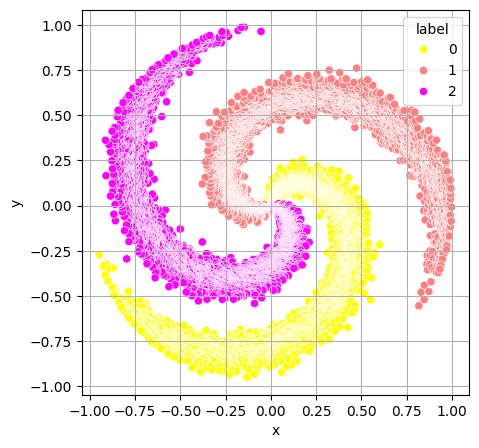

In [4]:
# generate and plot the data
generate_spirals()
spiral = pd.read_csv('spirals.csv')
plt.figure(figsize=(5, 5))
sns.scatterplot(x='x', y='y', data=spiral, hue='label', palette="spring_r");
plt.grid()
plt.show()

This is a classic example of data that is not linearly separable. It's a very simple dataset with 2 features, the x and y coordinates of a point, and one of 3 possible colors, indicated by the labels  0, 1 and 2. This data is clearly not linearly separable in 2D, thus neither linear regression nor our perceptron can correctly classify this data.

In [5]:
# let's look at the first 15 rows of the data
spiral.head(15)

,x,y,label
0,-0.000000,0.000000,0
1,0.000017,0.000249,0
2,-0.000015,0.000500,0
3,-0.000073,0.000747,0
4,0.000051,0.000999,0
5,-0.000426,0.001175,0
6,-0.000317,0.001466,0
7,-0.000366,0.001712,0
8,-0.000106,0.001998,0
9,-0.000193,0.002242,0


The data was generated and is organized by class, `train_test_split` will shuffle the data.

In [6]:
#let's look at the shape of our data

spiral.shape

(12000, 3)

The shape tells us number of instances (rows) and number of features (columns), in this case the label is included in the columns

<a id="perceptron"></a>
# Training a Perceptron on Non-linearly Separable data

## Partition into Training and Test set
---

The perceptron is a binary classifier, so let's try to predict yellow (class 0) vs non-yellow (classes 1 and 2 combined). So the labels are now 1 for is-yellow and 0 for not-yellow.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
# partition 20% of the data into the test set using train_test_split
X_train, X_test, y_train, y_test = train_test_split(spiral[['x','y']],
                                  (spiral[['label']] == 0).astype(int), test_size=0.2, random_state=42)

Look at the first few rows of your training set to confirm that `train_test_split` shuffled the data

In [9]:
X_train.head(10)

,x,y
9182,0.193798,-0.223173
11091,-0.772788,0.015487
6428,-0.118897,0.595396
288,0.031909,0.064563
2626,0.400848,-0.520124
8862,0.135067,-0.167989
3684,-0.397131,-0.831235
7971,0.991865,0.047422
6950,0.266993,0.687672
388,0.035312,0.090370


In [10]:
y_train.head(10)

,label
9182,0
11091,0
6428,0
288,1
2626,1
8862,0
3684,1
7971,0
6950,0
388,1


Sanity check: check the shape of your data to make sure you have the expeted number of rows and columns.

In [11]:
# now that we partitioned out the labels into y_train and y_test
# we see we only have two features (columns), the x and y coordinates
X_train.shape

(9600, 2)

In [12]:
y_train.shape

(9600, 1)

In [13]:
X_test.shape

(2400, 2)

In [14]:
y_test.shape

(2400, 1)

Now that we partitioned out the labels into y_train and y_test we see we only have two features (columns), the x and y coordinates

## Data Preprocessing
---

Our data is synthetic and already scaled between -1 and 1, so we don't need any preprocessing




## Select and Train the model
---




# Perceptron

In [15]:
# y_train is a DataFrame with shape (N, 1) — one column, N rows. .to_numpy() converts it to a 2D numpy array of shape (N, 1). 
# .flatten() collapses it into a 1D array of shape (N,).
r = y_train.to_numpy().flatten()

In [16]:
y_train.shape

(9600, 1)

In [17]:
r.shape

(9600,)

In [18]:
# Let's train a perceptron on this data and see how it does
from sklearn.linear_model import Perceptron

perc = Perceptron(
    max_iter=1000, random_state=42)
# Perceptron.fit() expects labels as a 1D array
perc.fit(X_train,r)



,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


## Evaluate the model
---

In [19]:
from sklearn.metrics import accuracy_score

y_hat = perc.predict(X_test)
accuracy = accuracy_score(y_test, y_hat)

accuracy

0.7675

In [20]:
# our data, spiral, has labels for the three colors, but we trained the
# perceptron on yellow vs non-yellow
# add a yellow vs non-yellow column for plotting
spiral['is_yellow'] = spiral[['label']] == 0
spiral



,x,y,label,is_yellow
0,-0.000000,0.000000,0,True
1,0.000017,0.000249,0,True
2,-0.000015,0.000500,0,True
3,-0.000073,0.000747,0,True
4,0.000051,0.000999,0,True
...,...,...,...,...
11995,-0.353531,0.934353,2,False
11996,-0.760809,0.647820,2,False
11997,-0.269305,0.962536,2,False
11998,-0.163305,0.986322,2,False


This is the best the Perceptron can do, and it's not so great! Indeed it is not possible to linearly separate the data.
Here is the Perceptron's linear decision boundary with predictions black = not_yellow and white = is_yellow

<Figure size 500x500 with 0 Axes>

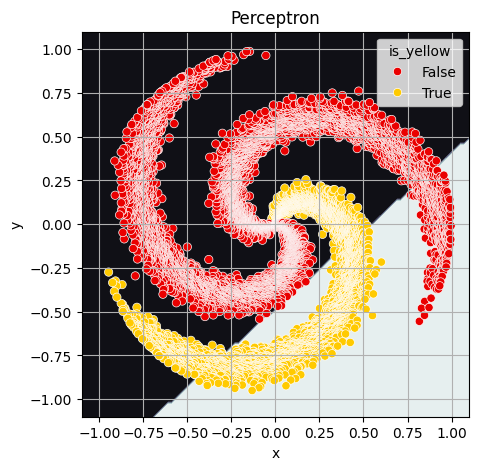

In [21]:
#@title Visualization Code

# decision boundary plot code adapted from
# https://scikit-learn.org/0.18/auto_examples/svm/plot_iris.html

plt.figure(figsize=(5, 5))

# create a mesh to plot in
h = .02 # step size in the mesh
x_min, x_max = X_train['x'].min() - 1, X_train['x'].max() + 1
y_min, y_max = X_train['y'].min() - 1, X_train['y'].max() + 1
#arange generates values in range with interval h.
#meshgrid organizes the coordinate vectors into coordinate matrix
# essentially the coordinates of a bunch of x,y points on the grid
# between x,y min and max
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Compute the decision boundary
#ravel() flattens into 1D
#np.c_ concatenates the two 1D arrays
#let the perceptron categorize every point in the mesh as yellow or non-yellow
mesh_df =  pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns = ['x','y'])
Z = perc.predict(mesh_df)


# Plot the decision boundary.
fig, ax = plt.subplots(figsize=(5,5),)
Z = Z.reshape(xx.shape) # reshape the predictiosn as grid for plotting
cntr = ax.contourf(xx, yy, Z, cmap=plt.cm.bone)

#plot the data
sns.scatterplot(ax=ax,x='x', y='y', data=spiral, hue='is_yellow', palette="hot");

ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)

ax.set_title('Perceptron')

plt.grid()
plt.show()

<a id="units"></a>
# Functional Units

Now let's explore how we can use other activation functions.   
Because we are working with a single unit, we must still cast the problem as binary classification, so we will continue to classify yellow vs non-yellow.

The goal here is to illustrate the shape of each activation function's decision surface, not to claim tanh/relu are good binary classifiers. We will show later on how these will be used as internal activation functions in larger neural networks.

Before we move on, we must introduce the two packages we will use in this course to train Neural Networks: **PyTorch** and **PyTorch Lightning**.

**PyTorch** is an open-source deep learning framework developed by Meta AI. It provides:
- `torch.nn`: building blocks for neural networks (layers, activations, loss functions)
- `torch.optim`: optimization algorithms (SGD, Adam, etc.)
- Automatic differentiation via `autograd` for computing gradients

https://pytorch.org/docs/stable/index.html

**PyTorch Lightning** is a high-level framework built on top of PyTorch. It organizes PyTorch code into a `LightningModule` — a class that bundles the model architecture, the loss, the optimizer, and the training/evaluation logic together. Training is then handled by a `Trainer` object with a single call, instead of writing explicit loops.

https://lightning.ai/docs/pytorch/stable/

This gives us the best of both worlds: the full flexibility and transparency of PyTorch, with the clean structure of a high-level API.

In practice, we define each model as a `LightningModule` subclass with three methods:
- `training_step`: what happens on each batch during training (forward pass, loss, logging)
- `test_step`: what happens on each batch during evaluation
- `configure_optimizers`: which optimizer to use

The `Trainer` then handles the epoch loop, gradient updates, `model.eval()` switching, and logging automatically.

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import lightning as L

In [23]:
# -----------------------------------------------------------------------
# DataLoader helpers and prediction utilities
#
# In Lightning, training/evaluation logic moves into LightningModule.
# We keep two small utilities here:
#   - make_binary_loader / make_multiclass_loader: wrap DataFrames into DataLoaders
#   - predict_binary / predict_multiclass: inference helpers for visualization
# -----------------------------------------------------------------------

def make_binary_loader(X, y, batch_size=32, shuffle=True):
    """Wrap X (DataFrame) and y (DataFrame, binary labels) into a DataLoader."""
    X_t = torch.FloatTensor(X.values.copy())                                                                   
    y_t = torch.FloatTensor(y.values.copy()).reshape(-1, 1)                                                    
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def make_multiclass_loader(X, y, batch_size=32, shuffle=True):
    """Wrap X (DataFrame) and y (DataFrame, integer class labels) into a DataLoader."""
    X_t = torch.FloatTensor(X.values.copy())
    y_t = torch.LongTensor(y.values.copy().flatten())
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def predict_binary(model, X):
    """Run inference with a binary model. X can be a DataFrame or ndarray."""
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X.values if hasattr(X, 'values') else X)
        return model.net(X_t).numpy()


def predict_multiclass(model, X):
    """Run inference with a multiclass model. Returns softmax probabilities as numpy array."""
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X.values if hasattr(X, 'values') else X)
        return torch.softmax(model.net(X_t), dim=1).numpy()




In [24]:
# -----------------------------------------------------------------------
# BinaryUnit: a LightningModule for a single functional unit (binary classification)
# -----------------------------------------------------------------------

class BinaryUnit(L.LightningModule):
    """A single functional unit (one neuron) for binary classification.

    Args:
        activation: any nn.Module activation (nn.Sigmoid(), nn.Tanh(), nn.ReLU(), ...)

    Note on the clamping hack: BCE loss requires inputs in (0, 1). Sigmoid outputs
    are already in that range, but tanh outputs [-1, 1] and relu outputs [0, ∞).
    We clamp the output to [eps, 1-eps] before computing the loss so that the same
    loss function can be used for all three activations and their decision surfaces
    can be directly compared. This is a pedagogical convenience — in production you
    would pair each output activation with its natural loss function.
    """
    def __init__(self, activation):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 1),   # 2 input features → 1 output unit
            activation
        )

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        X, y = batch
        output = self(X).clamp(1e-7, 1 - 1e-7)   # clamp before BCE (see note above)
        loss = F.binary_cross_entropy(output, y)
        acc = ((output >= 0.5).float() == y).float().mean()
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('train_acc',  acc,  on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        X, y = batch
        output = self(X).clamp(1e-7, 1 - 1e-7)
        loss = F.binary_cross_entropy(output, y)
        acc = ((output >= 0.5).float() == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=0.01)

## Select and Train the model
---

Let's now try to train different single-functional-unit models.

Keep in mind that the data is still labeled yellow / non-yellow

<a id="sigmoid"></a>
# Sigmoid

Let's start with the sigmoid activation function.


<img src="images/sigmoid.png" alt="sigmoid" width="600">

In [25]:
# sig_model: a single functional unit with sigmoid activation.
# Sigmoid squashes the output to [0, 1], which is the natural range for BCE loss —
# no clamping is actually needed here, but BinaryUnit applies it uniformly.

sig_model = BinaryUnit(nn.Sigmoid())

# Create DataLoaders: shuffle=True on train (re-shuffles each epoch), shuffle=False on test
train_loader = make_binary_loader(X_train, y_train, shuffle=True)
test_loader  = make_binary_loader(X_test,  y_test,  shuffle=False)

# Trainer handles the epoch loop, gradient zeroing, backward pass, optimizer step, and logging
trainer = L.Trainer(max_epochs=15, enable_model_summary=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [26]:
# recall, an epoch is a full pass over the training set
# Trainer.fit() trains sig_model for max_epochs=15 with mini-batch SGD (batch_size=32)
# 3200 training instances / 32 instances per mini-batch = 100 mini-batches per epoch
trainer.fit(sig_model, train_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


## Evaluate the model
---

Keep in mind that below we are evaluating the model on instances it has never seen during training — the test set.

`Trainer.test()` calls `test_step` on every batch of the test DataLoader and averages the logged metrics across all batches. With 2400 test instances and `batch_size=32`, that is 75 mini-batches. Loss and accuracy are averaged over all of them.

This is equivalent to running the forward pass on the full test set without updating any weights (`model.eval()` and `torch.no_grad()` are applied automatically by Lightning).

In [27]:
X_test.shape

(2400, 2)

In [28]:
# evaluate sig_model on the test set
# Trainer.test() runs test_step on each batch and reports the averaged metrics
trainer.test(sig_model, test_loader)

/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7954166531562805
        test_loss           0.4988669455051422
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.4988669455051422, 'test_acc': 0.7954166531562805}]

Below we visualize the decision boundary of the sigmoid. This is a smooth surface from 0 (black) to 1 (white).
The sigmoid outputs values between 0 and 1.  
 1.05 in the sidebar is simply a byproduct of the plotting which uses equal-size intervals for the colorbar.

Predictions:
 [[0.77720624]
 [0.7808535 ]
 [0.78445774]
 ...
 [0.04659771]
 [0.04754811]
 [0.04851691]]


/var/folders/64/wb5ckbx51jzbktv33n1gdxhw0000gn/T/ipykernel_74156/759258201.py:28: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  X_t = torch.FloatTensor(X.values if hasattr(X, 'values') else X)


<Figure size 500x500 with 0 Axes>

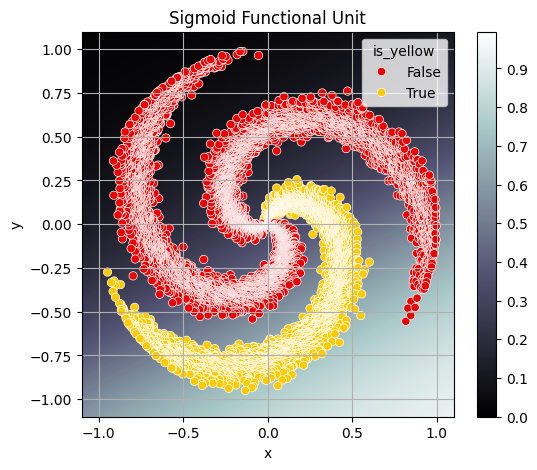

In [29]:
#@title Visualization Code

plt.figure(figsize=(5, 5))

# decision boundary for sigmoid
Z = predict_binary(sig_model, mesh_df)
print('Predictions:\n', Z)

# Plot the decision boundary.
fig, ax = plt.subplots(figsize=(6,5),)

Z = Z.reshape(xx.shape)
clev = np.arange(0, Z.max(), .001)
cntr = ax.contourf(xx, yy, Z, clev, cmap=plt.cm.bone)

cbar = fig.colorbar(cntr)

#plot the data
sns.scatterplot(ax=ax, x='x', y='y', data=spiral, hue='is_yellow', palette="hot")

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_title('Sigmoid Functional Unit')

plt.grid()
plt.show()


Note that here too we are classifying yellow vs non-yellow with a single functional unit, however the output now is continuous between 0-1.  

We have arbitrarily chosen 15 epochs here (more on how to parameterize that choice in the next lab!), but if you keep on training this unit, you will notice that there is no gain in accuracy. The same will be true for the following units.


## Select and Train the model
---

Single functional unit.

Data is still labeled yellow / non-yellow



<a id="tanh"></a>
#Hyperbolic Tangent


Let's try to use the hyperbolic tangent activation function (`tanh`)

<img src="images/tanh.png" alt="tanh" width="600">

In [30]:
# tanh_model: a single functional unit with hyperbolic tangent activation.
# nn.Tanh() squashes output to [-1, 1] — outside [0, 1], so BCE requires clamping.
# BinaryUnit handles this in training_step and test_step.

tanh_model = BinaryUnit(nn.Tanh())

train_loader = make_binary_loader(X_train, y_train, shuffle=True)
test_loader  = make_binary_loader(X_test,  y_test,  shuffle=False)
trainer = L.Trainer(max_epochs=15, enable_model_summary=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [31]:
# fit the model over 15 epochs
trainer.fit(tanh_model, train_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


## Evaluate the model
---

In [32]:
# evaluate the model on the test set
trainer.test(tanh_model, test_loader)

/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7337499856948853
        test_loss           0.46405714750289917
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.46405714750289917, 'test_acc': 0.7337499856948853}]

Note in the visualization of the decision boundary below, the `tanh` surface is steeper, indicated by the larger interval on the color bar (.25 instead of .15) and the larger range of values [-1,1] instead of [0,1]

Predictions:
 [[ 0.6958229 ]
 [ 0.7018906 ]
 [ 0.7078582 ]
 ...
 [-0.26271912]
 [-0.25164306]
 [-0.24050067]]


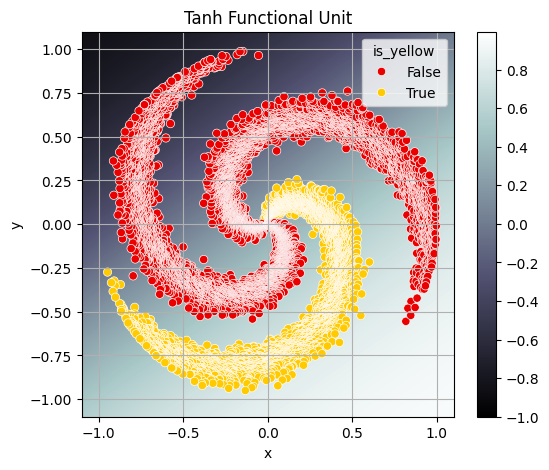

In [33]:
#@title Visualization Code

# decision boundary for tanh
Z = predict_binary(tanh_model, mesh_df)
print('Predictions:\n', Z)

# Plot the decision boundary.
fig, ax = plt.subplots(figsize=(6,5),)
Z = Z.reshape(xx.shape)

clev = np.arange(-1, Z.max(), .001)
cntr = ax.contourf(xx, yy, Z, clev, cmap=plt.cm.bone)
cbar = fig.colorbar(cntr)

#plot the data
sns.scatterplot(ax=ax, x='x', y='y', data=spiral, hue='is_yellow', palette="hot")

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_title('Tanh Functional Unit')

plt.grid()
plt.show()


## Select and Train the model
---

Single functional unit.

Data is still labeled yellow / non-yellow



<a id="relu"></a>
#Rectified Linear Unit

Finally, let's train a Rectified Linear Unit (`relu`) activation function

<img src="images/relu.png" alt="relu" width="600">

In [34]:
# relu_model: a single functional unit with ReLU activation.
# nn.ReLU() outputs max(0, x), so values are in [0, ∞) — also requires clamping for BCE.
# Note: ReLU is not a natural output-unit activation for classification; we use it here
# purely to compare its decision surface shape against sigmoid and tanh.

relu_model = BinaryUnit(nn.ReLU())

train_loader = make_binary_loader(X_train, y_train, shuffle=True)
test_loader  = make_binary_loader(X_test,  y_test,  shuffle=False)
trainer = L.Trainer(max_epochs=15, enable_model_summary=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [35]:
# fit the model over 15 epochs
trainer.fit(relu_model, train_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


## Evaluate the model
---

In [36]:
# evaluate the model on the test set
trainer.test(relu_model, test_loader)

/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7400000095367432
        test_loss           0.4577353298664093
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.4577353298664093, 'test_acc': 0.7400000095367432}]

In the `relu` decision boundary below we see a flat surface at 0 (black) that quickly slopes up above 0, with a color interval on the colorbar of 0.4 and values above 1 (somewhere between 1.2 and 1.6)
Once again, it is a byproduct of the plot colorbar to indicate regular intervals up to 2.8 even if these values do not appear in the plot.

Predictions:
 [[1.0038401]
 [1.0117357]
 [1.0196314]
 ...
 [0.       ]
 [0.       ]
 [0.       ]]


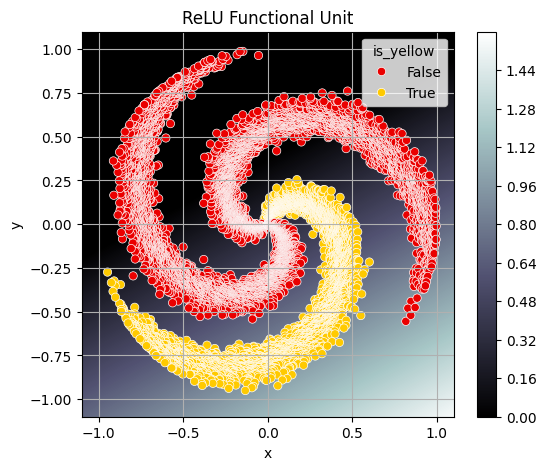

In [37]:
#@title Visualization Code

# decision boundary for relu
Z = predict_binary(relu_model, mesh_df)
print('Predictions:\n', Z)

# Plot the decision boundary.
fig, ax = plt.subplots(figsize=(6,5),)
Z = Z.reshape(xx.shape)
clev = np.arange(0, 1.6, .001)
cntr = ax.contourf(xx, yy, Z, clev, cmap=plt.cm.bone)
cbar = fig.colorbar(cntr)

#plot the data
sns.scatterplot(ax=ax, x='x', y='y', data=spiral, hue='is_yellow', palette="hot")

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_title('ReLU Functional Unit')

plt.grid()
plt.show()


Let's compare the three functional units


| Activation      | Losss |  Accuracy |
| ----------- | ----------- | --------
| Sigmoid      | 0.4909       |  0.7892 |
| TanH   | 0.4643     | 0.7329  |
| ReLU   | 0.4581  |0.7433   |

Compare the performance (loss and accuracy) of three functional units. How are these activation functions different? Compare the plots (look at the background) what are these functional units doing? Is one better than the other? Discuss with your partner.

We see that a single functional unit with a continuous activation function can give us a probability of the data being yellow or non-yellow. We could train 3 functional units, one for yellow vs non-yellow, one for peach vs non-peach and one for magenta vs non-magenta, then use all three to classify new data instances and take the one with highest probability.  

Or better yet ...

 Notice what each functional unit was actually doing: it was learning a single 
  smooth, nonlinear surface over the feature space, squashing or stretching it  
  through its activation function to push one class toward a high probability 
  and the other toward a low one. That surface is powerful — but it is still    
  fundamentally one surface, and no single surface can untangle a spiral. What 
  you observed in each unit — that its output is a continuous, nonlinear
  function of its inputs — is precisely the property we need to exploit at
  scale. When we **stack many such units in a hidden layer**, each one learns a
  different nonlinear transformation of the same input, collectively reshaping
  the feature space in ways no single unit could. Crucially, the activation
  function is what makes this stacking meaningful: without it, any number of
  stacked linear layers would collapse into a single linear transformation, no
  more powerful than the perceptron we started with. It is the **nonlinearity**,
  applied at every unit, that gives the network the expressive power to carve
  out the complex, **curved decision boundaries** that the spiral data demands.

<a name="ann"></a>
# Artificial Neural Networks

To achieve a non-linear decision boundary on a multiclass classification problem (distinguish between yellow, peach and magenta) we will train our first Artificial Neural Network (ANN).  
Essentially, we will stack multiple functional units with the same non-linear activation function in what we call a **hidden layer**.  

The **output layer** will be a stack of probabilistic functional units, in our case 3 sigmoids with Softmax over all the output units to guarantee that their sum is 1, forcing the network to convert the output of the three sigmoids into a probability that the instance belongs to that class.   

$\hat{\bf{y}} = softmax( z )_k = \hat{p}_k = \frac{e^{z_k}}{\sum_{j=1}^{\bf{K}}{e^{z_j}}}$

Then, argmax (the index that yelds the highest value) will select the class with highest probability to be the output of the network.

With this setup, our ANN will classify one of three classes (0 = yellow, 1 = peach, 2 = magenta).


This is (roughly) what our network will look like. We will hold the input and ouput layers still and tinker around with the hidden layer.

Be sure to understand this figure and how the equations fully define the network. Ask if you don't!

<img src="images/spiral_network.png" alt="spiral net" width="650">

*Figure 1*.


**Notation details:** In the network pictured above we have a single layer denoted by $\bf{h}$, and $h_j$ is the $j^{th}$ unit in the our hidden layer. In a multi-layer network we would have $\bf{h}^{(1)}$ for the first hidden layer, $\bf{h}^{(2)}$ for the second hidden layer, and so on, where $h^{(i)}_j$ is the $j^{th}$ node in the $i^{th}$ layer.

As usual we will:
1. [Partition the data into Training and Test set](#partition)
2. [Select and Train the Model](#model)
3. [Evaluate the Model](#evaluate)




<a name="partition"></a>
## Partition into Training, Validation, and Test set
---
Neural Networks support multiclass classification, so let's regenerate the data partition keeping all classes (yellow = 0, peach = 1, magenta = 2).

In a previous lab we mentioned k-fold cross-validation as the standard remedy for getting a reliable estimate of generalization error — training K models on different splits and averaging the results. We intentionally skipped it there, noting that neural networks call for a different approach.

Here is that approach: rather than training multiple models, we hold out a fixed **validation set** that is never used for weight updates. At the end of every epoch, Lightning evaluates the model on the validation set and reports the validation loss and accuracy alongside the training metrics.

This gives us a real-time view of how the model generalizes as training progresses. If training loss keeps decreasing but validation loss starts rising, the model is **overfitting** — memorizing the training data rather than learning patterns that generalize. The validation curve is our early warning signal for this. We will use it in the next lab to decide when to stop training.

The **test set** remains completely separate and is only used once, at the very end, to report final performance. The split we use is **60% train / 20% validation / 20% test**.

In [38]:
# 3-way split: 60% train / 20% validation / 20% test
# Step 1: hold out 20% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    spiral[['x','y']], spiral[['label']], test_size=0.2, random_state=42)

# Step 2: split the remaining 80% into 75% train / 25% val = 60% / 20% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42)

## Data Preprocessing
---

Recall, the data is artificial and already scaled, so no need for preprocessing.

<a name="model"></a>
## Select and Train the model
---

Let's start with 10 units in our hidden layer with the ReLU activation function.

An `nn.Sequential` model stacks layers in order with a single input and a single output. It can have different types of layers. An `nn.Linear` layer is a **fully connected** (dense) layer where every unit in one layer is connected to every unit in the next layer in a forward direction. A network with only `nn.Linear` layers is generally referred to as a **fully connected feed-forward network**, as depicted in the figure above.

For the ANN we define a `LightningModule` subclass called `SpiralNet` that bundles:
- the network architecture (in `self.net`)
- the loss function
- the training and evaluation logic (`training_step`, `test_step`)
- the optimizer (`configure_optimizers`)
- a `history` dict to record loss and accuracy per epoch for later visualization

<a name="initialize"></a>
## How to initialize the model and optimizer:

In [39]:
class EpochProgressBar(L.Callback):
    """Prints one line per epoch with train and validation loss and accuracy.
    Uses on_train_epoch_end because it fires after validation completes,
    so both train and val metrics are available in callback_metrics.
    """
    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        epoch    = trainer.current_epoch + 1
        total    = trainer.max_epochs
        loss     = metrics.get('train_loss', float('nan'))
        acc      = metrics.get('train_acc',  float('nan'))
        val_loss = metrics.get('val_loss',   float('nan'))
        val_acc  = metrics.get('val_acc',    float('nan'))
        print(f'Epoch {epoch}/{total} - loss: {loss:.4f} - accuracy: {acc:.4f}'
              f' - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}')

In [ ]:
class SpiralNet(L.LightningModule):
    """Fully connected feed-forward network for 3-class spiral classification."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # hidden layer: 2 inputs → 10 units, ReLU activation
            nn.Linear(2, 10),
            nn.ReLU(),
            # output layer: 10 units → 3 classes (raw logits — no softmax here)
            # nn.CrossEntropyLoss applies log-softmax internally
            nn.Linear(10, 3)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        X, y = batch
        output = self(X)
        loss = self.criterion(output, y)
        acc = (output.argmax(dim=1) == y).float().mean()
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('train_acc',  acc,  on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        output = self(X)
        loss = self.criterion(output, y)
        acc = (output.argmax(dim=1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  acc,  prog_bar=True)

    def on_train_epoch_end(self):
        # on_train_epoch_end fires after validation completes, so both train and
        # val metrics are available in callback_metrics at this point
        metrics = self.trainer.callback_metrics
        self.history['loss'].append(metrics['train_loss'].item())
        self.history['accuracy'].append(metrics['train_acc'].item())
        self.history['val_loss'].append(metrics['val_loss'].item())
        self.history['val_accuracy'].append(metrics['val_acc'].item())

    def test_step(self, batch, batch_idx):
        X, y = batch
        output = self(X)
        loss = self.criterion(output, y)
        acc = (output.argmax(dim=1) == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=0.01)

model = SpiralNet()

In [ ]:
train_loader = make_multiclass_loader(X_train, y_train, shuffle=True)
val_loader   = make_multiclass_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_multiclass_loader(X_test,  y_test,  shuffle=False)

In [ ]:
trainer = L.Trainer(
    max_epochs=30,
    callbacks=[EpochProgressBar()],
    enable_progress_bar=False,
    enable_model_summary=False,
    num_sanity_val_steps=0    # skip the pre-training sanity check to keep output clean
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Choosing the Loss

You may experiment with different optimizers (we will discuss more in future weeks), but **to choose the loss, keep in mind what kind of problem you are trying to solve**.

```python
# For a multi-class classification problem with integer class labels (e.g. y = [0, 2, 1]):
criterion = nn.CrossEntropyLoss()      # combines log-softmax + Negative Log Likelihood Loss (NLLLoss) internally 
# Note: the model should output raw logits (no softmax layer)

# For a binary classification problem with sigmoid output in [0, 1]:
criterion = nn.BCELoss()               # Binary Cross Entropy

# For a binary classification problem with raw logits (no sigmoid in the model):
criterion = nn.BCEWithLogitsLoss()     # numerically more stable — fuses sigmoid + BCE
```

We are now ready to train the model.

For now we will arbritrarily choose 30 epochs, but we don't know if this is enough (underfitting) or too much (overfitting). In the next lecture and lab we will talk about how to choose the epochs during training.
<a name="train"></a>
## How to train the model:


In [42]:
# train the model over 30 epochs with mini-batch SGD (batch_size=32)
# val_loader is evaluated at the end of every epoch — weights are never updated on it
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a

Epoch 1/30 - loss: 1.0735 - accuracy: 0.4210 - val_loss: 1.0242 - val_accuracy: 0.5275
Epoch 2/30 - loss: 0.9895 - accuracy: 0.5736 - val_loss: 0.9583 - val_accuracy: 0.5367
Epoch 3/30 - loss: 0.9239 - accuracy: 0.5442 - val_loss: 0.8959 - val_accuracy: 0.5333
Epoch 4/30 - loss: 0.8645 - accuracy: 0.5449 - val_loss: 0.8420 - val_accuracy: 0.5304
Epoch 5/30 - loss: 0.8157 - accuracy: 0.5475 - val_loss: 0.8009 - val_accuracy: 0.5383
Epoch 6/30 - loss: 0.7792 - accuracy: 0.5521 - val_loss: 0.7705 - val_accuracy: 0.5404
Epoch 7/30 - loss: 0.7528 - accuracy: 0.5565 - val_loss: 0.7500 - val_accuracy: 0.5437
Epoch 8/30 - loss: 0.7340 - accuracy: 0.5583 - val_loss: 0.7347 - val_accuracy: 0.5475
Epoch 9/30 - loss: 0.7203 - accuracy: 0.5610 - val_loss: 0.7237 - val_accuracy: 0.5504
Epoch 10/30 - loss: 0.7101 - accuracy: 0.5628 - val_loss: 0.7156 - val_accuracy: 0.5558
Epoch 11/30 - loss: 0.7025 - accuracy: 0.5671 - val_loss: 0.7102 - val_accuracy: 0.5525
Epoch 12/30 - loss: 0.6966 - accuracy: 0.

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30 - loss: 0.6472 - accuracy: 0.6008 - val_loss: 0.6612 - val_accuracy: 0.5846


Next, as we did with our functional units, we will evaluate the model and visualize the decision boundary.

<a name="evaluate"></a>
## Evaluate the model
---



In [43]:
# evaluate the model on the test set
# reports test_loss and test_acc averaged over the 2400 test instances
trainer.test(model, test_loader)

/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5912500023841858
        test_loss           0.6579350233078003
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6579350233078003, 'test_acc': 0.5912500023841858}]

Do you think this is doing better than the signle-activation unit? Is this network solving the same problem as the single functional units were? Discuss with your partner. Then look at the plot of the decision boundary. How is it different?

Predictions (softmax probabilities):
 [[1.2521851e-01 2.5766020e-04 8.7452382e-01]
 [1.3387169e-01 2.6107056e-04 8.6586720e-01]
 [1.4302495e-01 2.6434488e-04 8.5671073e-01]
 ...
 [4.1729560e-05 9.9995828e-01 1.3797617e-08]
 [3.9272229e-05 9.9996078e-01 1.2653133e-08]
 [3.6959558e-05 9.9996305e-01 1.1603577e-08]]
argmax(Predictions):
 [2 2 2 ... 1 1 1]
values in argmax(Predictions):
 (array([0, 1, 2]), array([12688, 14091, 12227]))


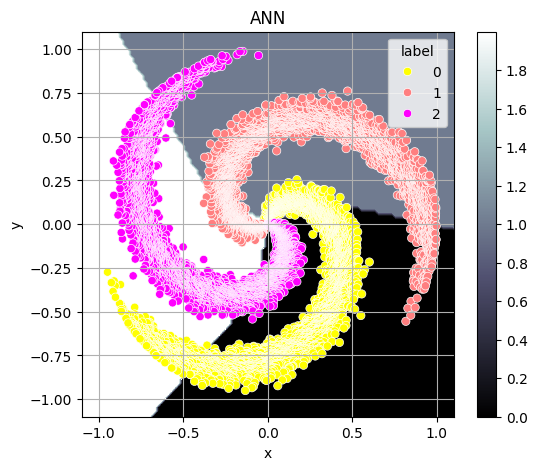

In [44]:
#@title Visualization Code

# decision boundary for ANN
Z = predict_multiclass(model, mesh_df)
print('Predictions (softmax probabilities):\n', Z)

# Plot the decision boundary.
fig, ax = plt.subplots(figsize=(6,5),)
Z = Z.argmax(axis=1)
print('argmax(Predictions):\n', Z)
print('values in argmax(Predictions):\n', np.unique(Z, return_counts=True))
Z = Z.reshape(xx.shape)
clev = np.arange(0, 2, .001)
cntr = ax.contourf(xx, yy, Z, clev, cmap=plt.cm.bone)
cbar = fig.colorbar(cntr)

#plot the data
sns.scatterplot(ax=ax, x='x', y='y', data=spiral, hue='label', palette="spring_r")

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_title('ANN')

plt.grid()
plt.show()


**Look at that decision boundary!!!**

Increasing the number of epochs on the single functional units did not improve accuracy, but try to continue training this network a little longer.

### Now try the following:

* What happens if you train for 60 epochs? (Just run `trainer.fit()` again with the same `model`, `train_loader`, and `val_loader` — Lightning will continue from where it left off.) Re-evaluate and observe the decision boundary.
* What happens after you train for 90 epochs? Re-evaluate and observe the decision boundary.
* Now play around with the architecture of the network! What happens if you change the number of units? The number of layers? Try it out and watch how the decision boundary changes.
* Discuss with your partner.

**IMPORTANT:** If you call `trainer.fit()` again on the same `model`, Lightning continues training from the current weights. To **retrain from scratch with freshly initialized weights**, you must re-instantiate both the model and the trainer, then call `fit()` again:
```python
model = SpiralNet()          # re-initializes weights
trainer = L.Trainer(max_epochs=60, callbacks=[EpochProgressBar()], enable_progress_bar=False, num_sanity_val_steps=0)
trainer.fit(model, train_loader, val_loader)
```
Note that `model.history` will also reset when you re-instantiate `SpiralNet()`, so the training curve will reflect only the new run. If you change the architecture (e.g. number of units or layers), you must always re-instantiate.

So what number of hidden units should you choose? How many hidden layer? What activation function?

There is no single network architecture that is guaranteed to learn well.
There is no magic number for the parameters either. There are some general guidelines, but you must always experiment and it is ultimately dependent on the data.

Finally, how long should we train? When should we stop training? More on this next week.


Now let's visualize the training process. `model.history` records loss and accuracy for both the training and validation sets at the end of every epoch. Plotting them together is the standard way to monitor training and spot overfitting:

<Axes: >

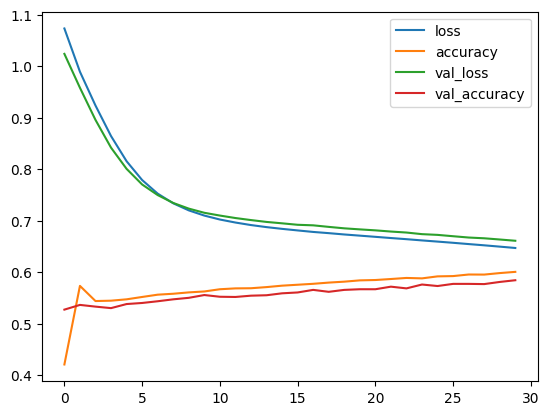

In [45]:
# model.history has 4 keys: 'loss', 'accuracy', 'val_loss', 'val_accuracy'
# one value per epoch, collected by on_validation_epoch_end
loss = pd.DataFrame(model.history)
loss.plot()

What does this plot mean? Why is it important? Discuss with your partner.

The `loss` DataFrame has one row per epoch and four columns: `loss`, `accuracy`, `val_loss`, `val_accuracy`. Training and validation curves can be plotted individually for a clearer view:

In [46]:
# look at the first few rows of the loss dataframe
loss.head()

,loss,accuracy,val_loss,val_accuracy
0,1.073504,0.420972,1.024167,0.527500
1,0.989488,0.573611,0.958349,0.536667
2,0.923868,0.544167,0.895945,0.533333
3,0.864543,0.544861,0.842015,0.530417
4,0.815677,0.547500,0.800868,0.538333


<Axes: >

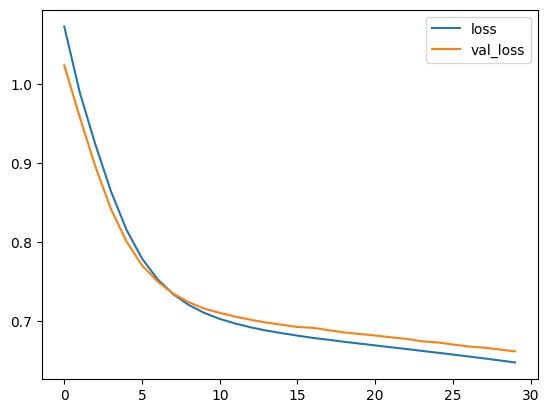

In [47]:
# plot train and validation loss together
loss[['loss', 'val_loss']].plot()

<Axes: >

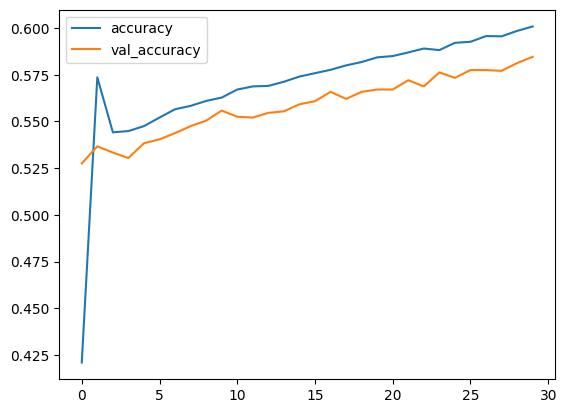

In [48]:
# plot train and validation accuracy together
loss[['accuracy', 'val_accuracy']].plot()

This is what happened to the loss and accuracy during training. This is one way to monitor training and, in conjunction with a validation set, next week we will monitor the loss to decide when to stop training.  
Now let's look at the details of how our model fares on the test set. We already saw the summary results of evaluating over `X_test`, let's run it again here:

In [49]:
trainer.test(model, test_loader)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5912500023841858
        test_loss           0.6579350233078003
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


[{'test_loss': 0.6579350233078003, 'test_acc': 0.5912500023841858}]

Let's now look at the actual model predictions on the test set and compare them with the true labels.

In [50]:
# predict on the test set
# predict_multiclass applies softmax and returns class probabilities as a numpy array
predictions = predict_multiclass(model, X_test)
predictions

array([[0.70111597, 0.24889986, 0.04998417],
       [0.04526794, 0.92565125, 0.02908085],
       [0.7085469 , 0.23271035, 0.0587428 ],
       ...,
       [0.06125696, 0.7549285 , 0.18381457],
       [0.18349363, 0.01794756, 0.79855883],
       [0.25163913, 0.30477187, 0.44358906]],
      shape=(2400, 3), dtype=float32)

What do these numbers mean? Discuss with your partner.

In [51]:
# the predictions are probabilities for each class that add up to 1 (thanks to softmax)
# we want the argmax: the index of the column with the largest value,
# i.e. the class with the highest probability
# we pass index=X_test.index so y_hat shares the same (shuffled) index as y_test,
# allowing pd.concat to align them correctly without any index manipulation
y_hat = pd.DataFrame(
    predictions.argmax(axis=1),
    columns=['y_hat'],
    index=X_test.index
)

Look at the predictions and the true labels, how do they compare?


In [52]:
# visualize the predictions
y_hat

,y_hat
1935,0
6494,1
1720,0
9120,0
360,1
...,...
1195,1
11877,1
5421,1
3855,2


In [53]:
# visualize the true labels
y_test

,label
1935,0
6494,1
1720,0
9120,2
360,0
...,...
1195,0
11877,2
5421,1
3855,0


The code below assumes familiarity with the `pandas` package. [Here is a pandas tutorial](https://www.datacamp.com/community/tutorials/) if you need to refresh on concatenating and renaming columns in dataframes.

In [54]:
# both y_hat and y_test share the same shuffled index (from train_test_split),
# so we can concatenate them directly — no index reset needed
eval_df = pd.concat([y_hat, y_test], axis=1)
eval_df.rename(columns={'label': 'True Label'}, inplace=True)
eval_df

,y_hat,True Label
1935,0,0
6494,1,1
1720,0,0
9120,0,2
360,1,0
...,...,...
1195,1,0
11877,1,2
5421,1,1
3855,2,0


### Confusion Matrix

Let's visualize the actual predictions with a confusion matrix:

In [55]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# let's look again at the types and shapes
print(y_hat.shape)
print(y_test.shape)
print(type(y_hat))
print(type(y_test))


(2400, 1)
(2400, 1)
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


Text(50.722222222222214, 0.5, 'true labels')

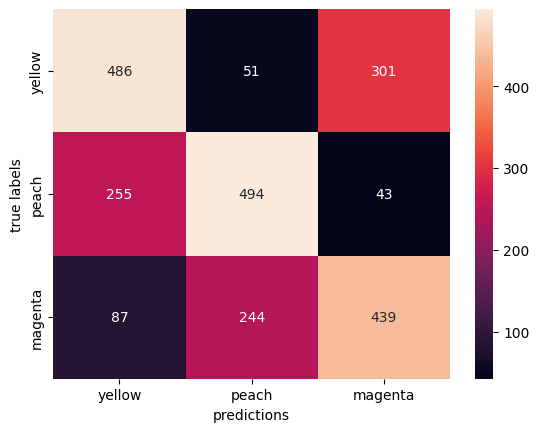

In [56]:
# confusion_matrix expects 1d arrays, so we convert the dataframes to 1d numpy arrays
conf_matrix = confusion_matrix(y_hat.to_numpy().ravel(), y_test.to_numpy().ravel())
print('\n\n\n')
labels = ['yellow', 'peach', 'magenta']
ax = sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=labels, yticklabels=labels)
ax.set_xlabel('predictions')
ax.set_ylabel('true labels')


We want light colors along the diagonal (correctlyclassified) and dark colors everywhere else (missclassified).